# EDA
## Projektbeskrivning
RightHome är en bostadsplattform som hjälper användare att hitta rätt bostad 
på rätt plats. I denna EDA undersöker vi bostadsdata från hela Sverige för 
att förstå hur pris, område, upplåtelseform och servicetillgång hänger ihop.

## Syfte
- Förstå prisstrukturen på den svenska bostadsmarknaden
- Identifiera vilka faktorer som påverkar bostadspriset mest
- Hitta mönster och insikter som kan stödja RightHomes rekommendationssystem


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset
Vi arbetar med fyra datakällor:
- `bostader.csv` – Bostadsinformation (typ, rum, boyta, upplåtelseform)
- `priser.csv`   – Prisinformation per bostad (pris, avgift, kvm-pris)
- `platser.csv`  – Områdesinformation (område, stad, befolkning)
- `visningar.csv`– Visningsdata per bostad


In [16]:
df_bostader  = pd.read_csv("../ETL_Pipline/bostader.csv")
df_platser   = pd.read_csv("../ETL_Pipline/platser.csv")
df_priser    = pd.read_csv("../ETL_Pipline/priser.csv")
df_visningar = pd.read_csv("../ETL_Pipline/visningar.csv")

df_bostader.head()

,id,typ,upplåtelseform,rum,boyta,boyta_enhet,tillgänglig,created_at,adress,lat,lon,plats_id,sparad,poi_kollektivtrafik,poi_utbildning_kultur,poi_mat_shopping,poi_fritid,poi_religion_tro,poi_halsa,poi_ovrigt
0,1,hus,köpa,4,108,m²,True,2025-08-29,Drottninggatan 28,59.33820,17.94255,1,0,0,0,0,0,0,0,0
1,2,hus,köpa,6,138,m²,True,2026-03-18,Skolvägen 104,55.58171,13.03274,2,0,0,0,0,0,0,0,0
2,3,lägenhet,hyra,3,75,m²,True,2025-09-22,Drottninggatan 90,55.60470,12.96912,3,0,0,0,0,0,0,0,0
3,4,lägenhet,köpa,3,69,m²,True,2026-01-01,Kyrkogatan 33,57.69446,11.96088,4,0,0,0,0,0,0,0,0
4,5,lägenhet,hyra,2,42,m²,False,2025-09-14,Hornsgatan 94,55.58295,12.93665,5,0,0,0,0,0,0,0,0


In [18]:
print(df_bostader.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     1000 non-null   int64  
 1   typ                    1000 non-null   object 
 2   upplåtelseform         1000 non-null   object 
 3   rum                    1000 non-null   int64  
 4   boyta                  1000 non-null   int64  
 5   boyta_enhet            1000 non-null   object 
 6   tillgänglig            1000 non-null   bool   
 7   created_at             1000 non-null   object 
 8   adress                 1000 non-null   object 
 9   lat                    1000 non-null   float64
 10  lon                    1000 non-null   float64
 11  plats_id               1000 non-null   int64  
 12  sparad                 1000 non-null   int64  
 13  poi_kollektivtrafik    1000 non-null   int64  
 14  poi_utbildning_kultur  1000 non-null   int64  
 15  poi_m

In [19]:
print(df_platser.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   område             20 non-null     object
 1   stad               20 non-null     object
 2   plats_id           20 non-null     int64 
 3   kommun_befolkning  20 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 772.0+ bytes
None


In [20]:
print(df_priser.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bostad_id         1000 non-null   int64  
 1   pris              1000 non-null   int64  
 2   avgift            1000 non-null   int64  
 3   kvadratmeterpris  1000 non-null   int64  
 4   pris_per_kvm      1000 non-null   float64
 5   valuta            1000 non-null   object 
dtypes: float64(1), int64(4), object(1)
memory usage: 47.0+ KB
None


In [21]:
print(df_visningar.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   bostad_id      2 non-null      int64 
 1   adress         2 non-null      object
 2   visningsdatum  2 non-null      object
 3   starttid       2 non-null      object
 4   sluttid        2 non-null      object
dtypes: int64(1), object(4)
memory usage: 212.0+ bytes
None


In [22]:
print(df_bostader.describe())

                id          rum        boyta          lat          lon  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    500.500000     3.489000    80.937000    57.528627    14.316432   
std     288.819436     1.684255    41.233084     1.539000     2.660319   
min       1.000000     1.000000    18.000000    55.552060    11.890160   
25%     250.750000     2.000000    46.000000    55.602618    11.961630   
50%     500.500000     4.000000    80.000000    57.704910    12.975235   
75%     750.250000     5.000000   112.000000    59.312503    17.977963   
max    1000.000000     6.000000   168.000000    59.392160    18.172530   

          plats_id       sparad  poi_kollektivtrafik  poi_utbildning_kultur  \
count  1000.000000  1000.000000          1000.000000                 1000.0   
mean      8.522000     0.003000             0.002000                    0.0   
std       5.295806     0.054717             0.063246                    0.0   
min       1.00000

In [23]:
print(df_bostader.shape)
print(df_bostader.dtypes)
print(df_bostader.isnull().sum())

(1000, 20)
id                         int64
typ                       object
upplåtelseform            object
rum                        int64
boyta                      int64
boyta_enhet               object
tillgänglig                 bool
created_at                object
adress                    object
lat                      float64
lon                      float64
plats_id                   int64
sparad                     int64
poi_kollektivtrafik        int64
poi_utbildning_kultur      int64
poi_mat_shopping           int64
poi_fritid                 int64
poi_religion_tro           int64
poi_halsa                  int64
poi_ovrigt                 int64
dtype: object
id                       0
typ                      0
upplåtelseform           0
rum                      0
boyta                    0
boyta_enhet              0
tillgänglig              0
created_at               0
adress                   0
lat                      0
lon                      0
plats_id          

In [27]:
print(df_priser.columns)
print(df_bostader.columns)


Index(['bostad_id', 'pris', 'avgift', 'kvadratmeterpris', 'pris_per_kvm',
       'valuta'],
      dtype='object')
Index(['id', 'typ', 'upplåtelseform', 'rum', 'boyta', 'boyta_enhet',
       'tillgänglig', 'created_at', 'adress', 'lat', 'lon', 'plats_id',
       'sparad', 'poi_kollektivtrafik', 'poi_utbildning_kultur',
       'poi_mat_shopping', 'poi_fritid', 'poi_religion_tro', 'poi_halsa',
       'poi_ovrigt'],
      dtype='object')


## Analysens struktur
1. Datainläsning & ihopslagning
2. Datakvalitet & saknade värden
3. Prisanalys per område
4. Prisanalys per upplåtelseform
5. Prisanalys per antal rum
6. Storytelling-visualiseringar

In [28]:
# Visa snittpris per upplåtelseform
df_merged = df_bostader.merge(df_priser, left_on="id", right_on="bostad_id")

df_merged.groupby("upplåtelseform")["pris"].mean().reset_index()

,upplåtelseform,pris
0,hyra,1.172048e+04
1,köpa,5.595048e+06


In [29]:
# Kolla bostäder med pris under 10 000

df_priser[df_priser["pris"] < 10000]

,bostad_id,pris,avgift,kvadratmeterpris,pris_per_kvm,valuta
4,5,7077,0,0,168.0,SEK
5,6,5255,0,0,138.0,SEK
10,11,9242,0,0,134.0,SEK
16,17,5722,0,0,130.0,SEK
26,27,6582,0,0,127.0,SEK
...,...,...,...,...,...,...
969,970,9395,0,0,125.0,SEK
970,971,7500,0,0,156.0,SEK
972,973,5047,0,0,140.0,SEK
992,993,3327,0,0,133.0,SEK


In [30]:
print(df_bostader[["id", "adress", "plats_id"]].head(10))

   id             adress  plats_id
0   1  Drottninggatan 28         1
1   2      Skolvägen 104         2
2   3  Drottninggatan 90         3
3   4      Kyrkogatan 33         4
4   5      Hornsgatan 94         5
5   6      Parkvägen 117         6
6   7       Storgatan 16         5
7   8      Bergsgatan 70         7
8   9      Hornsgatan 71         8
9  10  Drottninggatan 89         4


In [31]:
print(df_platser.head(10))

          område       stad  plats_id  kommun_befolkning
0         Bromma  Stockholm         1             995574
1      Rosengård      Malmö         2             365644
2  Västra Hamnen      Malmö         3             365644
3    Linnéstaden   Göteborg         4             608993
4        Limhamn      Malmö         5             365644
5          Nacka  Stockholm         6             995574
6        Majorna   Göteborg         7             608993
7       Hisingen   Göteborg         8             608993
8      Hägersten  Stockholm         9             995574
9         Hyllie      Malmö        10             365644


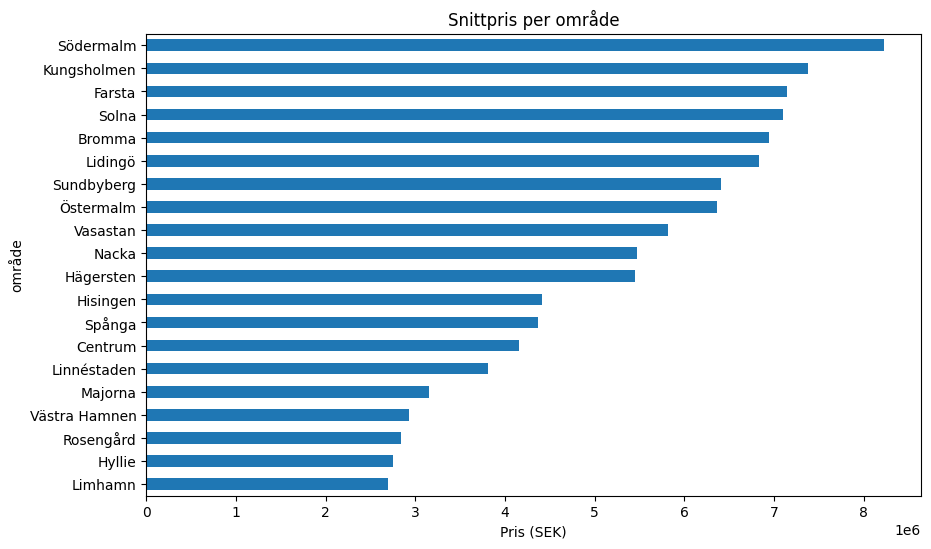

In [32]:
# Visa snittpris per område
df_merged2 = df_merged.merge(df_platser, on="plats_id")

df_merged2.groupby("område")["pris"].mean().sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Snittpris per område")
plt.xlabel("Pris (SEK)")
plt.show()

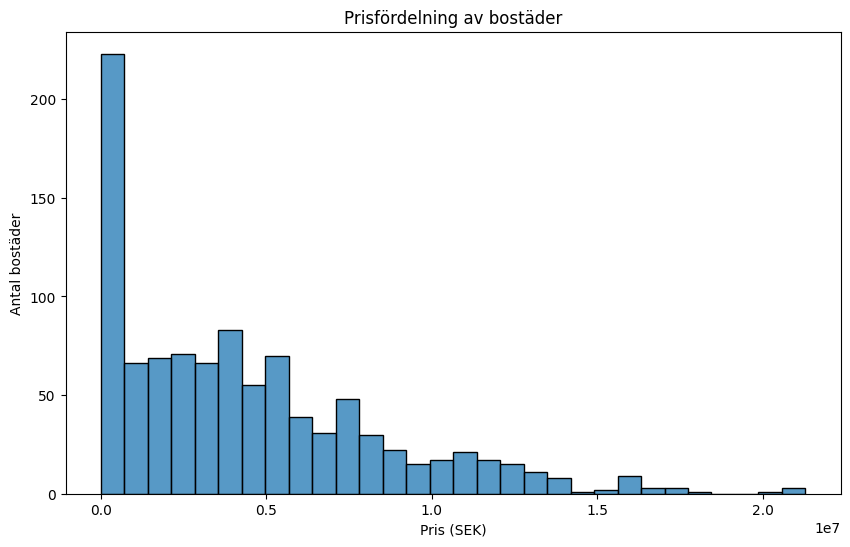

In [35]:
# Visa prisfördelning
plt.figure(figsize=(10,6))
sns.histplot(df_merged2["pris"], bins=30)
plt.title("Prisfördelning av bostäder")
plt.xlabel("Pris (SEK)")
plt.ylabel("Antal bostäder")
plt.show()

#### Använder SQL för att analysera data på ett strukturerat sätt, precis som man skulle göra mot en riktig databas 

In [36]:
import duckdb 

# Använd DuckDB för att köra SQL-frågor på DataFrame
con = duckdb.connect()
con.register("right_home", df_merged2)


In [37]:
con.execute("SELECT * FROM right_home LIMIT 5").df()

,id,typ,upplåtelseform,rum,boyta,boyta_enhet,tillgänglig,created_at,adress,lat,...,poi_ovrigt,bostad_id,pris,avgift,kvadratmeterpris,pris_per_kvm,valuta,område,stad,kommun_befolkning
0,1,hus,köpa,4,108,m²,True,2025-08-29,Drottninggatan 28,59.33820,...,0,1,11411993,4177,105666,105667.0,SEK,Bromma,Stockholm,995574
1,2,hus,köpa,6,138,m²,True,2026-03-18,Skolvägen 104,55.58171,...,0,2,6959222,2820,50429,50429.0,SEK,Rosengård,Malmö,365644
2,3,lägenhet,hyra,3,75,m²,True,2025-09-22,Drottninggatan 90,55.60470,...,0,3,10345,0,0,138.0,SEK,Västra Hamnen,Malmö,365644
3,4,lägenhet,köpa,3,69,m²,True,2026-01-01,Kyrkogatan 33,57.69446,...,0,4,3484199,3983,50495,50496.0,SEK,Linnéstaden,Göteborg,608993
4,5,lägenhet,hyra,2,42,m²,False,2025-09-14,Hornsgatan 94,55.58295,...,0,5,7077,0,0,168.0,SEK,Limhamn,Malmö,365644


In [38]:
# Visa snittpris per område med SQL
con.execute("""
    SELECT område, 
           ROUND(AVG(pris), 0) as snittpris,
           COUNT(*) as antal
    FROM right_home
    GROUP BY område
    ORDER BY snittpris DESC
""").df()

,område,snittpris,antal
0,Södermalm,8228287.0,34
1,Kungsholmen,7376875.0,25
2,Farsta,7142941.0,30
3,Solna,7099196.0,19
4,Bromma,6939687.0,32
5,Lidingö,6831457.0,24
6,Sundbyberg,6408391.0,28
7,Östermalm,6361763.0,20
8,Vasastan,5818599.0,35
9,Nacka,5472857.0,34


In [39]:
# hyra mot köp 
con.execute("""
    SELECT upplåtelseform,
           COUNT(*) as antal,
           ROUND(AVG(pris), 0) as snittpris,
           MIN(pris) as lägsta,
           MAX(pris) as högsta
    FROM right_home
    GROUP BY upplåtelseform
""").df()

,upplåtelseform,antal,snittpris,lägsta,högsta
0,köpa,781,5595048.0,574315,21282713
1,hyra,219,11720.0,2166,28140


In [40]:
# Tillgängliga bostäder per stad 
con.execute("""
    SELECT stad,
           COUNT(*) as antal,
           SUM(CASE WHEN tillgänglig = true THEN 1 ELSE 0 END) as tillgängliga
    FROM right_home
    GROUP BY stad
""").df()

,stad,antal,tillgängliga
0,Malmö,339,266.0
1,Göteborg,329,244.0
2,Stockholm,332,241.0


In [ ]:
import os
print(os.getcwd())

/Users/zinebmouhib/Documents/UX25_DE25_Projekt_Group3/notebooks


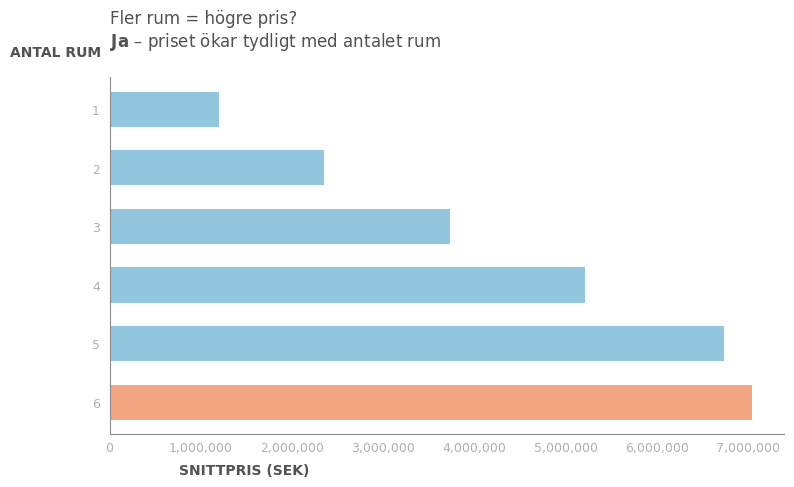

In [49]:
GRAY_1 = "#8c8c8c"
GRAY_2 = "#b0b0b0"
GRAY_3 = "#525252"

df_plot3 = df_merged2.groupby("rum")["pris"].mean().sort_values()
max_val = df_plot3.idxmax()
colors3 = ["#f4a582" if k == max_val else "#92c5de" for k in df_plot3.index]

fig, ax = plt.subplots(figsize=(8, 5))
df_plot3.plot(kind="barh", ax=ax, width=0.6, color=colors3)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRAY_1)

ax.tick_params(axis="both", colors=GRAY_2, labelsize=9, length=0, pad=5)
ax.tick_params(axis="y", pad=7)

ax.set_xlabel("SNITTPRIS (SEK)", color=GRAY_3, fontweight="bold")
ax.set_ylabel("ANTAL RUM", color=GRAY_3, fontweight="bold", rotation=0)
ax.yaxis.set_label_coords(-0.08, 1.05)
ax.xaxis.set_label_coords(0.2, -0.08)

ax.set_title(
    "Fler rum = högre pris?\n"
    + r"$\bf{Ja}$"
    + " – priset ökar tydligt med antalet rum",
    loc="left", color=GRAY_3, pad=22
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.invert_yaxis()
fig.tight_layout()
plt.show()

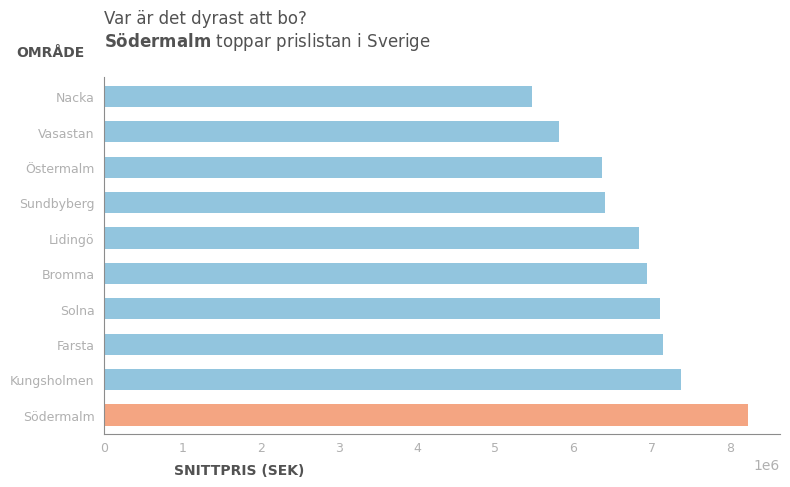

In [52]:
GRAY_1 = "#8c8c8c"
GRAY_2 = "#b0b0b0"
GRAY_3 = "#525252"


df_plot2 = df_merged2.groupby("område")["pris"].mean().sort_values(ascending=False).head(10)

top_område = df_plot2.idxmax()  # hämtar det faktiska toppområdet dynamiskt
colors2 = ["#f4a582" if o == top_område else "#92c5de" for o in df_plot2.sort_values().index]

fig, ax = plt.subplots(figsize=(8, 5))
df_plot2.sort_values().plot(kind="barh", ax=ax, width=0.6, color=colors2)

ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRAY_1)

ax.tick_params(axis="both", colors=GRAY_2, labelsize=9, length=0, pad=5)
ax.tick_params(axis="y", pad=7)

ax.set_xlabel("SNITTPRIS (SEK)", color=GRAY_3, fontweight="bold")
ax.set_ylabel("OMRÅDE", color=GRAY_3, fontweight="bold", rotation=0)
ax.yaxis.set_label_coords(-0.08, 1.05)
ax.xaxis.set_label_coords(0.2, -0.08)

ax.set_title(
    "Var är det dyrast att bo?\n"
    + r"$\bf{" + top_område + "}$"
    + " toppar prislistan i Sverige",
    loc="left", color=GRAY_3, pad=22
)

ax.invert_yaxis()
fig.tight_layout()
plt.show()
